In [ ]:
"""
Better organized science plots. Use cmz_scratch.ipynb for scratch work
"""
import sys
import os.path

path = "~/apps/kratos/visual"
full_path = os.path.expanduser(path)

%env KRATOS_VISUAL_DIR=$full_path
sys.path.append( "../visual" )
from proxy import *
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
%autoreload 2
#%aimport binary_io
#%aimport hydro_data
#%aimport slice_plot
#%aimport cmz_init
%aimport proxy
%matplotlib inline

env: KRATOS_VISUAL_DIR=/home/cmz_colab/apps/kratos/visual


soxs : [WARNING  ] 2026-06-07 22:46:10,053 Setting 'soxs_data_dir' to /home/cmz_colab/.cache/soxs for this session. Please update your configuration if you want it somewhere else.


file: ../cmz/cmz_test/outputs/cmz_fid4_b60_00054.bin; time = 270


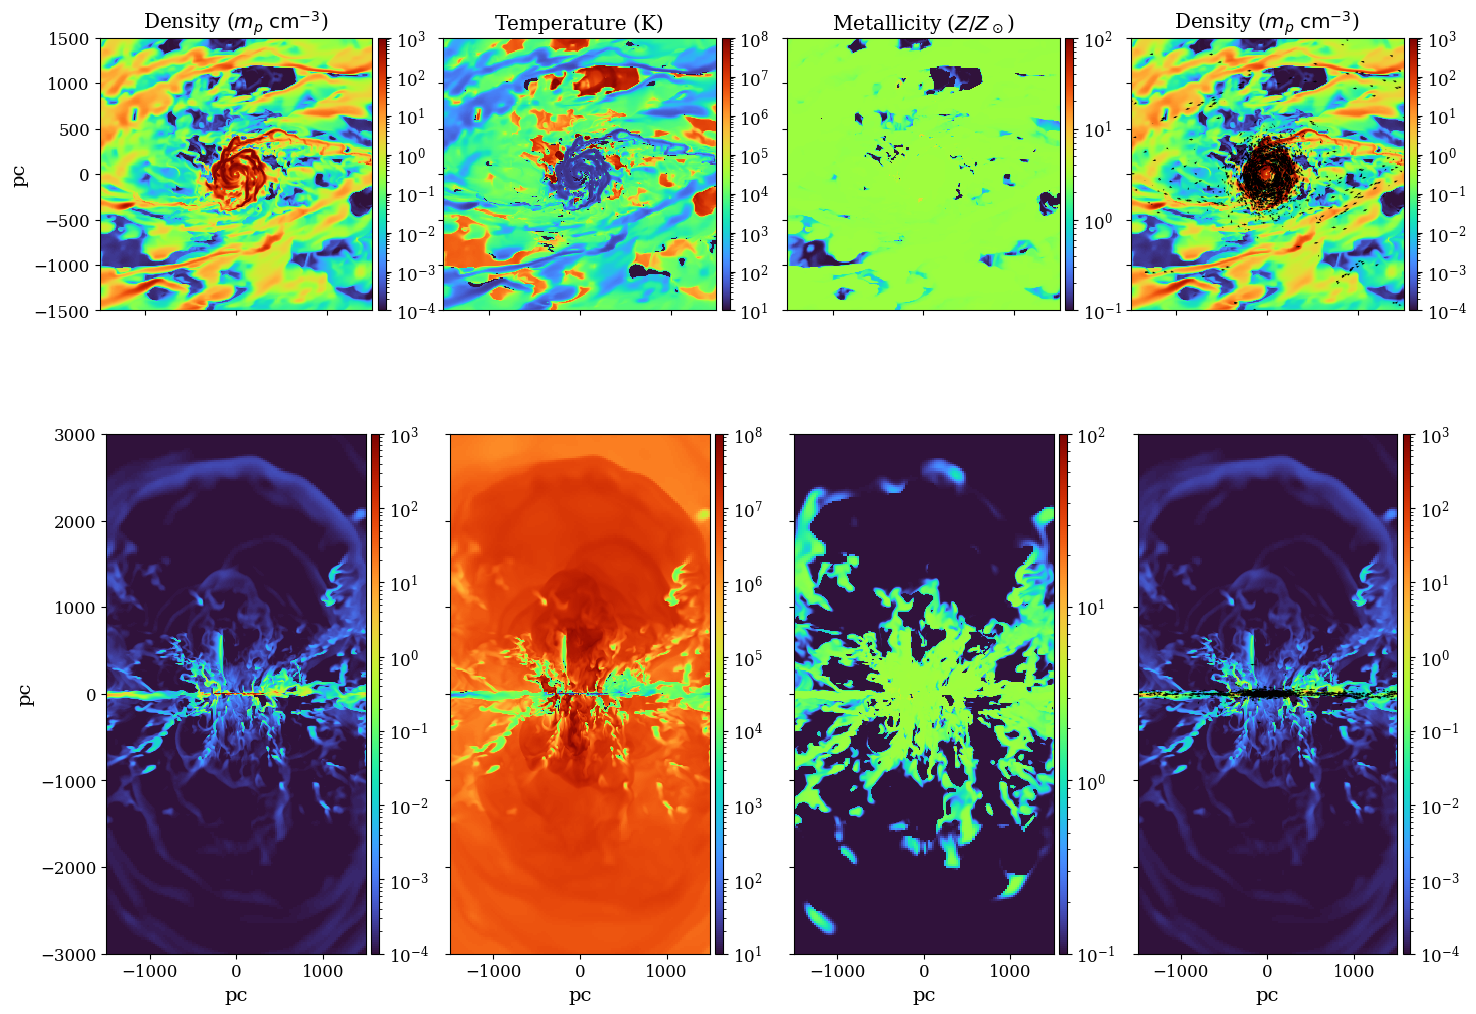

In [2]:
#d  = get_last_dd( f'../cmz/cmz_test/outputs/cmz_fb3_b3e3_{fstring( 30 )}.bin', -1, enroll_prim=True, data_type = galaxy_data );
d  = get_last_dd( f'../cmz/cmz_test/outputs/cmz_fid4_b60_{fstring( 54 )}.bin', -1, enroll_prim=True, data_type = galaxy_data );
fig2 = f_plot_grid( d,  figsize=( 17, 13.5 )# , 
                    #,xlims = [ ( -12000, 12000 ), ( -12000, 12000 ) ] 
                    #,ylims = [ ( -12000, 12000 ), ( -12000, 12000 ) ]#,
                    #log   = [ True, True, True, False ],
                    #locs  = [ [ 1e-2, 1e-2, 1e-2, 2 ], [ 1e-2, 1e-2, 1e-2, 1e-2, 1e-2 ] ],
                    #axes  = 2,
                    #z0s   = [ 1, 1, -1, 1 / ( 4 * np.pi * G_code ) ],
                    #z0s   = [ 1, 1, 1, 1, -1 ],
                    #flds  = [ 'rho', 'T_ent', 'met', 'rho' ],
                    #zlims = [ ( 1e-4, 1e4 ), ( 1e1, 1e8 ), ( 1e-1, 1e2 ), ( 1e-2, 1e3 ) ],
                    #part_plot_i = [] )#( 1e-4, 1 ) ] )
                    )

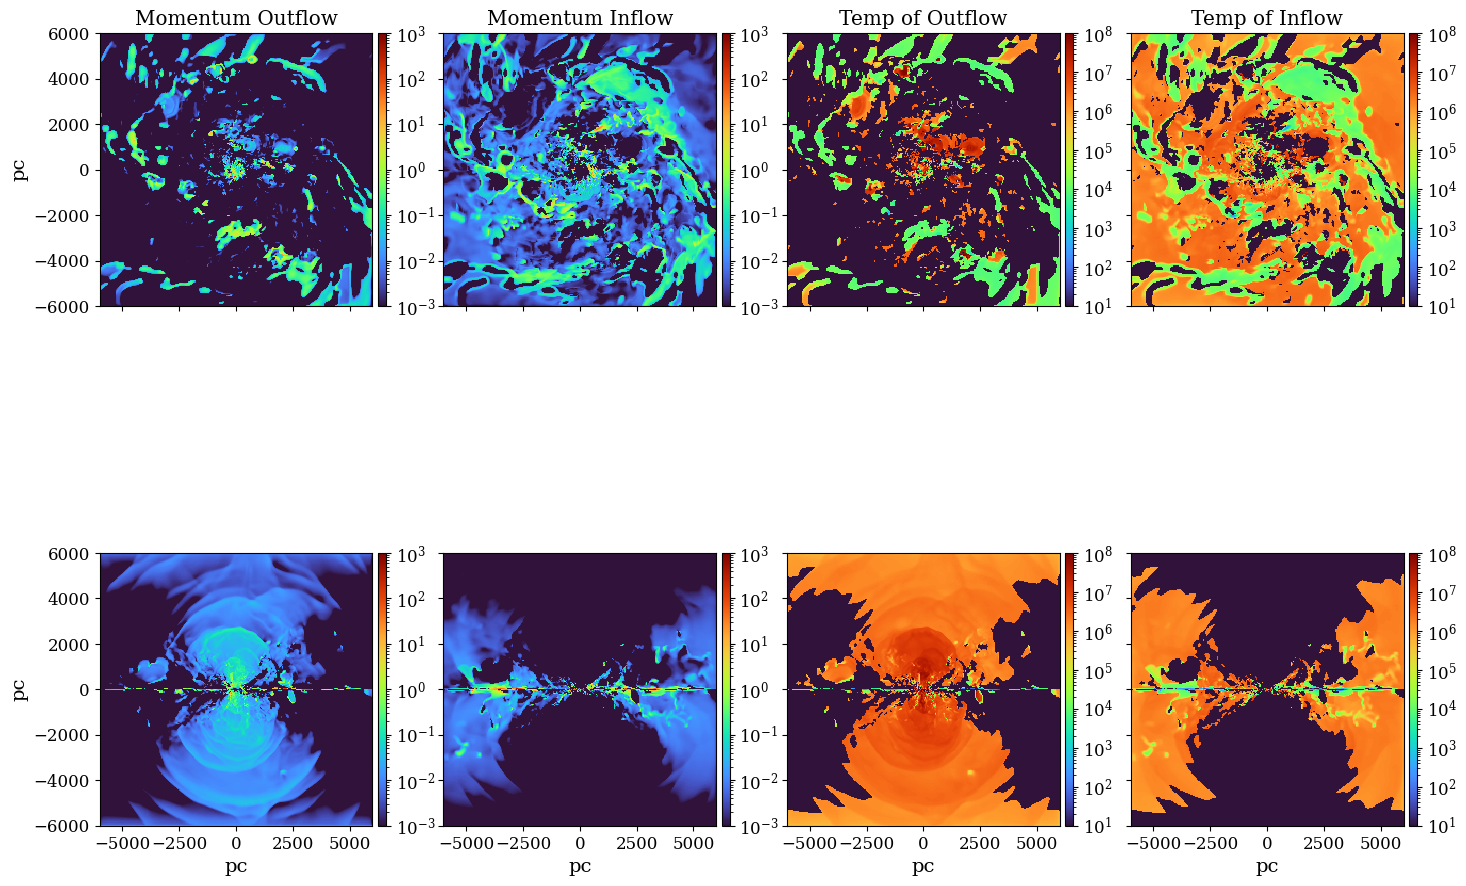

In [3]:
%reload_ext autoreload
#d  = get_last_dd( f'../cmz/cmz_test/outputs/cmz_fb4_nobondi_{fstring( 20 )}.bin', -1, enroll_prim=True, data_type = cmz_data );
#enroll_flux( d, 'mass', lambda bd : bd[ 'rho' ] * np.prod( bd[ 'dx' ], axis=0 ) )
#enroll_flux( d, 'met_fld' )
enroll_vel( d )
enroll_sgn( d, 'mom' )
enroll_sgn( d, "T_ent", "sgnvel" )
enroll_sgn( d, "met", "sgnvel" )

#R<500 z<140 definition of CMZ per 3-D CMZ battersby+2024

fig2 = f_plot_grid( d,  figsize=( 17, 13.5 ), 
                    xlims = [ ( -6000, 6000 ), ( -6000, 6000 ) ], 
                    ylims = [ ( -6000, 6000 ), ( -6000, 6000 ) ],
                    #log   = [ True, True, True, False ],
                    locs  = [ [ 140, 140, 140, 140 ],#, 140, 140 ], 
                              [ 1e-2, 1e-2, 1e-2, 1e-2 ] ],#, 1e-2, 1e-2 ] ],
                    #axes  = 2,
                    #z0s   = [ 1, 1, -1, 1 / ( 4 * np.pi * G_code ) ],
                    z0s   = [ 1, -1, 1, -1 ],#, 1, -1 ],
                    flds  = [ 'sgnmom[2]', 'sgnmom[2]', 'sgnT_ent[2]', 'sgnT_ent[2]' ],#, 'sgnflux_met_fld[2]', 'sgnflux_met_fld[2]' ],
                    names = [ 'Momentum Outflow', "Momentum Inflow", "Temp of Outflow", "Temp of Inflow" ],#,"Met Outflow", "Met Inflow" ],
                    zlims = [ ( 1e-3,1e3 ), ( 1e-3, 1e3 ), ( 1e1, 1e8 ), ( 1e1, 1e8 ) ],#, ( 1e-4,1e4 ), ( 1e-4, 1e4 ) ],
                    part_plot_i = [] )#( 1e-4, 1 ) ] )

/mnt/scratch/cmz/notebooks/../kratos_galaxy/visual/plot_gal.py:387: UserWarning: Log scale: values of z <= 0 have been masked
  s = contour_func( xcenters, ycenters, counts.T,


(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='$\\rho$ ($m_p$ cm$^{-3}$)', ylabel='$T$ (K)'>)

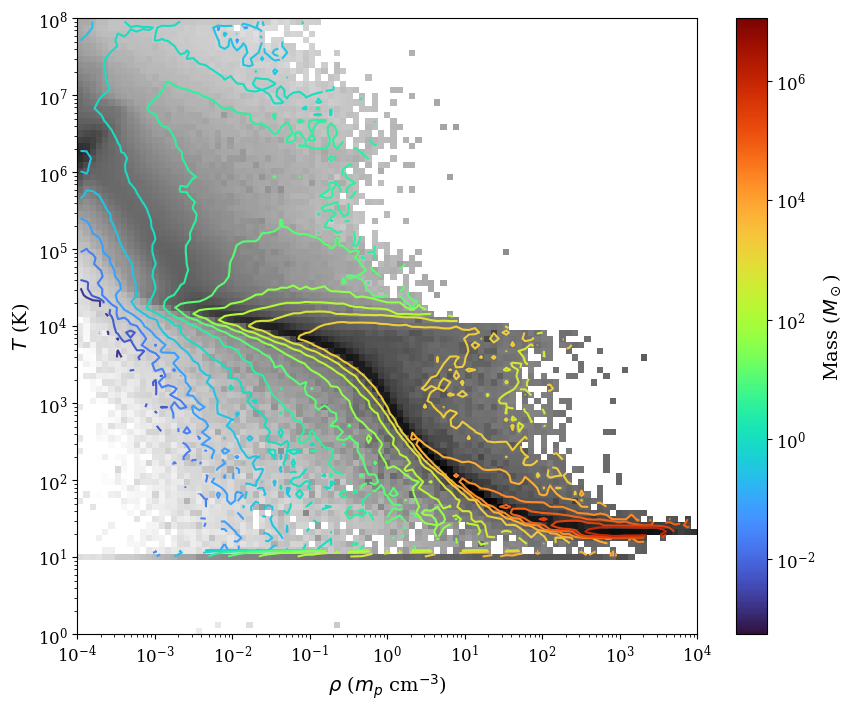

In [4]:
fig, ax = plt_phase( d, cmap="Greys", show_cbar=False, figsize=( 10, 8 ) )
plt_phase( d, fig=fig, ax=ax, plot_contour=True, contour_fill=False, levels=20, R_out = 500, Z_out = 140 )

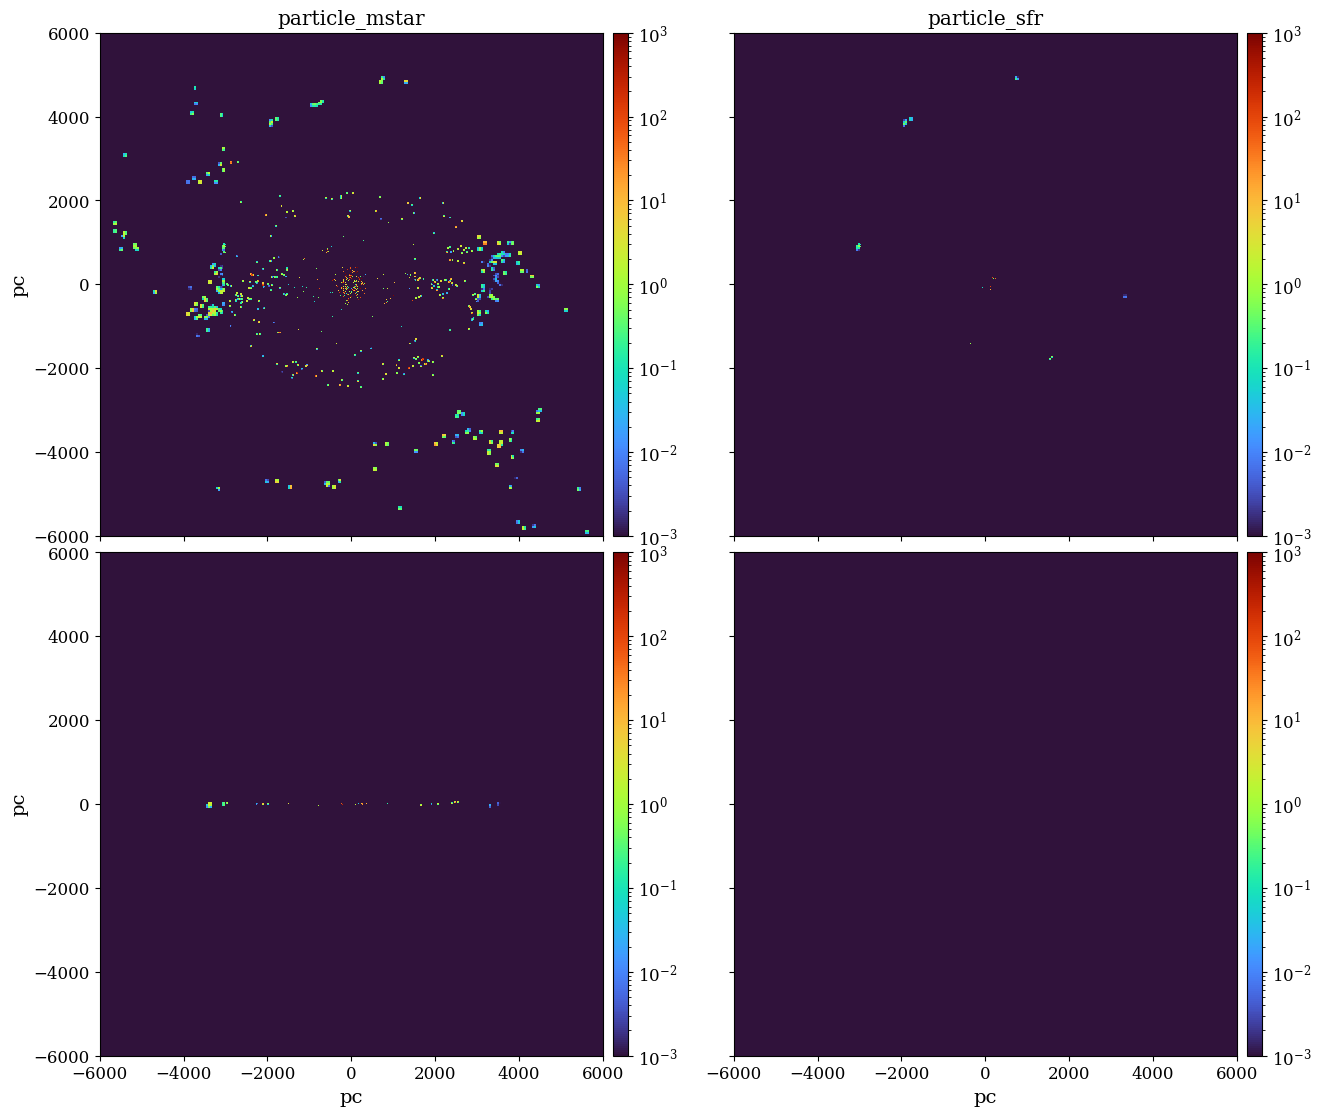

In [5]:
enroll_mesh_tree( d )
map_particle_blk( d, "particle_mstar", "particle_sfr" )
fig3 = f_plot_grid( d,  figsize=( 15, 13.5 ),
                    xlims = [ ( -6000, 6000 ), ( -6000, 6000 ) ], 
                    ylims = [ ( -6000, 6000 ), ( -6000, 6000 ) ],
                   flds = [ 'particle_mstar', "particle_sfr" ],
                   part_plot_i = [] )

/tmp/ipykernel_1390410/1609533543.py:21: RuntimeWarning: overflow encountered in multiply
  ax.hist(( mstar[ in_cmz ] )*m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),
/tmp/ipykernel_1390410/1609533543.py:25: RuntimeWarning: overflow encountered in multiply
  ax.hist(( mstar[ in_cmz & recent ] )         *m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),


2587


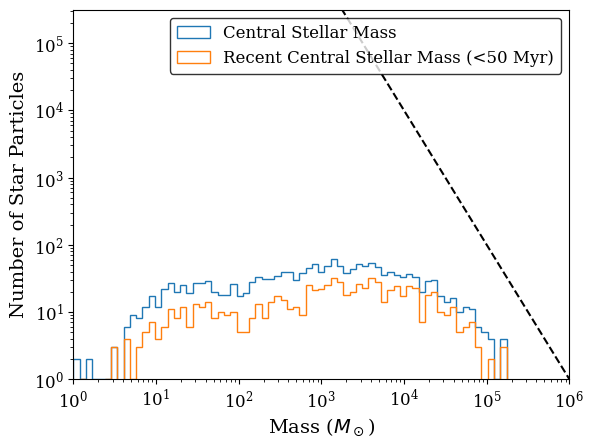

In [6]:
d_out = d
r = np.sqrt( np.sum( d_out.data['particle_x'].T**2, axis=0 ) )
R = np.sqrt( np.sum( d_out.data['particle_x'].T[ :2 ]**2, axis=0 ) )
z = d_out.data['particle_x'].T[ 2 ]
tcreate = d_out.data['particle_tcreate']
age     = d_out.data['particle_age']

in_cmz = ( R < 500 ) & ( np.abs( z ) < 140 )
recent = age < 50

mstar = d_out.data['particle_mstar']
m = d_out.data['particle_m']
sfr = d_out.data['particle_sfr']
SFdelay = d_out.data['particle_SFdelay']
RS0 = d_out.data['particle_RS0']
f,ax = plt.subplots()

xminlog = 0
xmaxlog = 6

ax.hist(( mstar[ in_cmz ] )*m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),
         histtype='step',fill=False,stacked=False, label='Central Stellar Mass')
#ax.hist(( m    [ in_cmz ] )*m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),
#         histtype='step',fill=False,stacked=False, label='Central Total Mass')
ax.hist(( mstar[ in_cmz & recent ] )         *m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),
         histtype='step',fill=False,stacked=False, label='Recent Central Stellar Mass (<50 Myr)')
#ax.hist(( m )         *m0/modot,bins=10**np.linspace( xminlog, xmaxlog, 80 ),
#         histtype='step',fill=False,stacked=False, label='Recent Central Mass')
#ax.hist(( m - mstar )*m0/modot,bins=10**np.linspace(1,5,80),
#         histtype='step',fill=False,stacked=False, label='Gas Mass')
ax.set_xscale('log')
ax.set_yscale('log')
x = 10**np.linspace(2,10,100)
ax.plot(x, 10**12*x**-2, '--k')
ax.set_xlabel(r"Mass ($M_\odot$)")
plt.xlim([10**xminlog,10**xmaxlog])
ax.set_ylim([1e0,10**5.5])
ax.set_ylabel("Number of Star Particles")
ax.legend()
print( len( m ) )


Text(0, 0.5, 'Stellar Mass Formed ($M_\\odot$)')

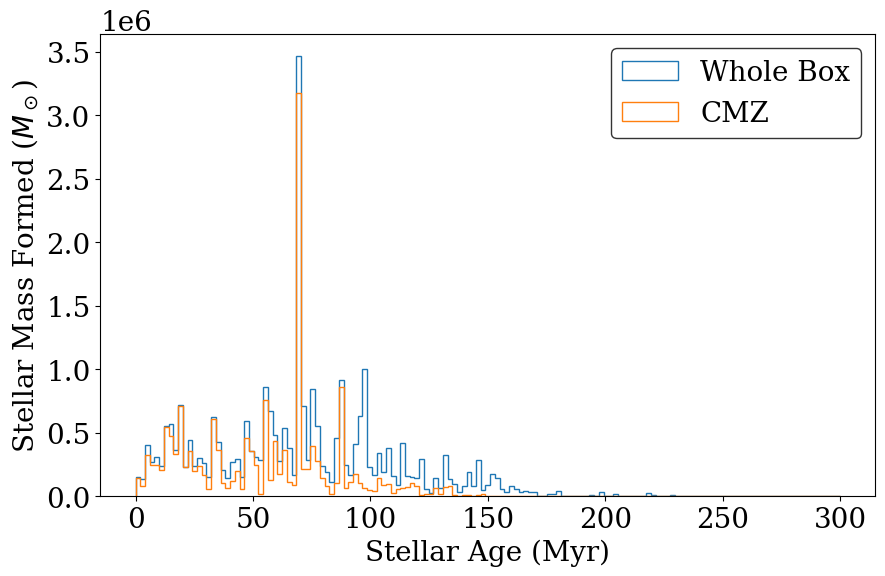

In [22]:
plt.rcParams['font.size'] = 20
f,ax = plt.subplots(1,1,figsize=( 10, 6 ) )
conv = m0 / modot
tcreate = d_out.data['particle_tcreate']
age     = d_out.data['particle_age']
bins = np.linspace( 0, 300, 150 )
ax.hist( age, weights=mstar*conv, bins=bins, histtype='step', fill=False, label='Whole Box' )
ax.hist( age[ in_cmz ], weights=mstar[ in_cmz ]*conv, bins=bins, histtype='step', fill=False, label='CMZ' )
ax.legend( fontsize=20 )
ax.set_xlabel( "Stellar Age (Myr)",fontsize=20 )
ax.set_ylabel( "Stellar Mass Formed ($M_\odot$)",fontsize=20 )

Text(0, 0.5, 'Stellar Mass Formed/$\\Delta t$ ($M_\\odot$)')

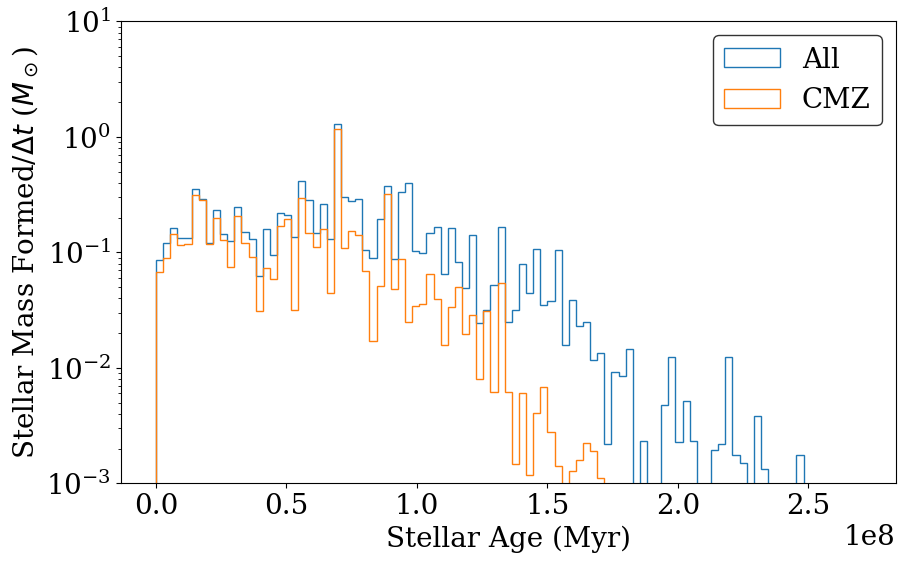

In [25]:
filter = par_pos_cut( d, 500, [ -140, 140 ], coord='cyl' )
all_ages = d_out.data['particle_age'] * 1e6
cmz_ages = d_out.data['particle_age'][ filter ] * 1e6
mstar    = d_out.data['particle_mstar']
bins = np.linspace( 0, d_out.globals['time']*1e6, 100 )
conv = m0 / modot / np.diff( bins )[ 0 ]
f,ax = plt.subplots(1,1,figsize=( 10, 6 ) )
ax.hist( all_ages, weights=mstar*conv, bins=bins, histtype='step', fill=False, label='All' )
ax.hist( cmz_ages, weights=mstar[ filter ]*conv, bins=bins, histtype='step', fill=False, label='CMZ' )
ax.set_yscale( 'log' )
ax.set_ylim( [1e-3, 1e1] )
ax.legend( fontsize=20 )
ax.set_xlabel( "Stellar Age (Myr)",fontsize=20 )
ax.set_ylabel( "Stellar Mass Formed/$\Delta t$ ($M_\odot$)",fontsize=20 )

In [8]:
cmz_mstar = np.sum( ( mstar )[ in_cmz ] ) * m0 / modot / 1e8
cmz_sfr = np.sum(sfr[ in_cmz ]) * m0 / modot / ( t0 / yr )
cmz_sfrv2 = np.sum(sfr[ (SFdelay == 0) & in_cmz ]) * m0 / modot / ( t0 / yr )
print( cmz_mstar, cmz_sfr )

0.1647676579562615 0.046389835193294135


In [9]:
d_out.data.keys( )

dict_keys(['block_0', 'block_100', 'block_101', 'block_102', 'block_103', 'block_104', 'block_105', 'block_106', 'block_107', 'block_108', 'block_109', 'block_10', 'block_110', 'block_111', 'block_112', 'block_113', 'block_114', 'block_115', 'block_116', 'block_117', 'block_118', 'block_119', 'block_11', 'block_120', 'block_121', 'block_122', 'block_123', 'block_124', 'block_125', 'block_126', 'block_127', 'block_128', 'block_129', 'block_12', 'block_130', 'block_131', 'block_132', 'block_133', 'block_134', 'block_135', 'block_136', 'block_137', 'block_138', 'block_139', 'block_13', 'block_140', 'block_141', 'block_142', 'block_143', 'block_144', 'block_145', 'block_146', 'block_147', 'block_148', 'block_149', 'block_14', 'block_150', 'block_151', 'block_152', 'block_153', 'block_154', 'block_155', 'block_156', 'block_157', 'block_158', 'block_159', 'block_15', 'block_160', 'block_161', 'block_162', 'block_163', 'block_164', 'block_165', 'block_166', 'block_167', 'block_168', 'block_16

In [10]:
dyt = load_kratos_yt( d_out, fld_extra = [ "particle_mstar", "particle_sfr" ] )

yt : [WARNING  ] 2026-06-07 22:49:06,449 Overriding code units: Use this option only if you know that the dataset doesn't define the units correctly or at all.
yt : [INFO     ] 2026-06-07 22:49:06,451 Overriding length_unit: 3.0857e+18 cm.
yt : [INFO     ] 2026-06-07 22:49:06,452 Overriding time_unit: 31536000000000.0 s.
yt : [INFO     ] 2026-06-07 22:49:06,453 Overriding mass_unit: 4.914262907092623e+31 g.
yt : [WARNING  ] 2026-06-07 22:49:06,454 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-06-07 22:49:06,526 Parameters: current_time              = 270.00014757331695
yt : [INFO     ] 2026-06-07 22:49:06,526 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-06-07 22:49:06,527 Parameters: domain_left_edge          = [-6000. -6000. -6000.]
yt : [INFO     ] 2026-06-07 22:49:06,528 Parameters: domain_right_edge         = [6000. 6000. 6000.]
yt : [INFO     ] 2026-06-07 22:49:06,529 Parameters: cosmological_simulation   = 0


yt : [INFO     ] 2026-06-07 22:49:07,964 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:07,965 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:07,967 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:07,968 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:07,970 Making a fixed resolution buffer of (('gas', 'temperature')) 800 by 800



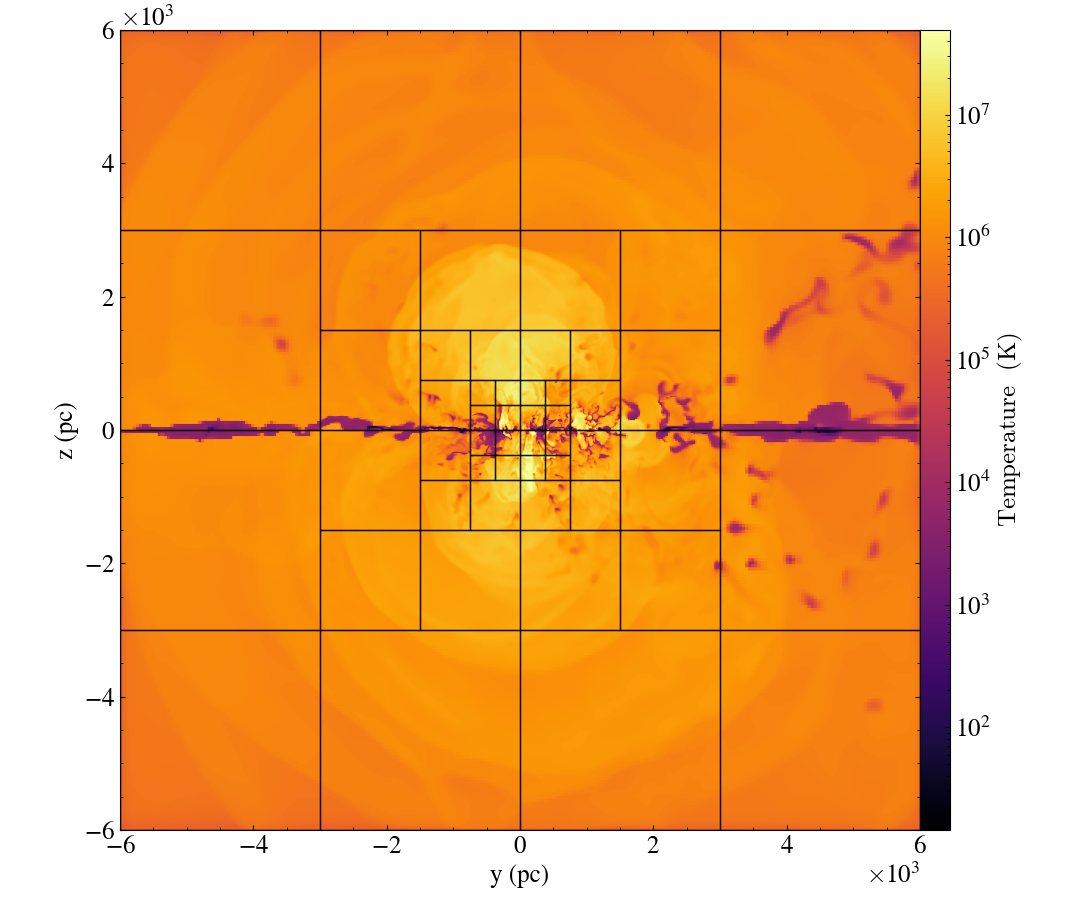

In [11]:
import yt


slc = yt.SlicePlot(dyt, "x", ("gas", "temperature"))
slc.set_cmap(("gas", "temperature"), "inferno")
slc.set_unit(("gas", "temperature"), "K")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)

#slc.save("yt_temp.png")
slc.show()

yt : [INFO     ] 2026-06-07 22:49:34,702 Projection completed
yt : [INFO     ] 2026-06-07 22:49:34,705 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:34,706 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:34,709 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:34,710 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:34,712 Making a fixed resolution buffer of (('gas', 'temperature')) 800 by 800



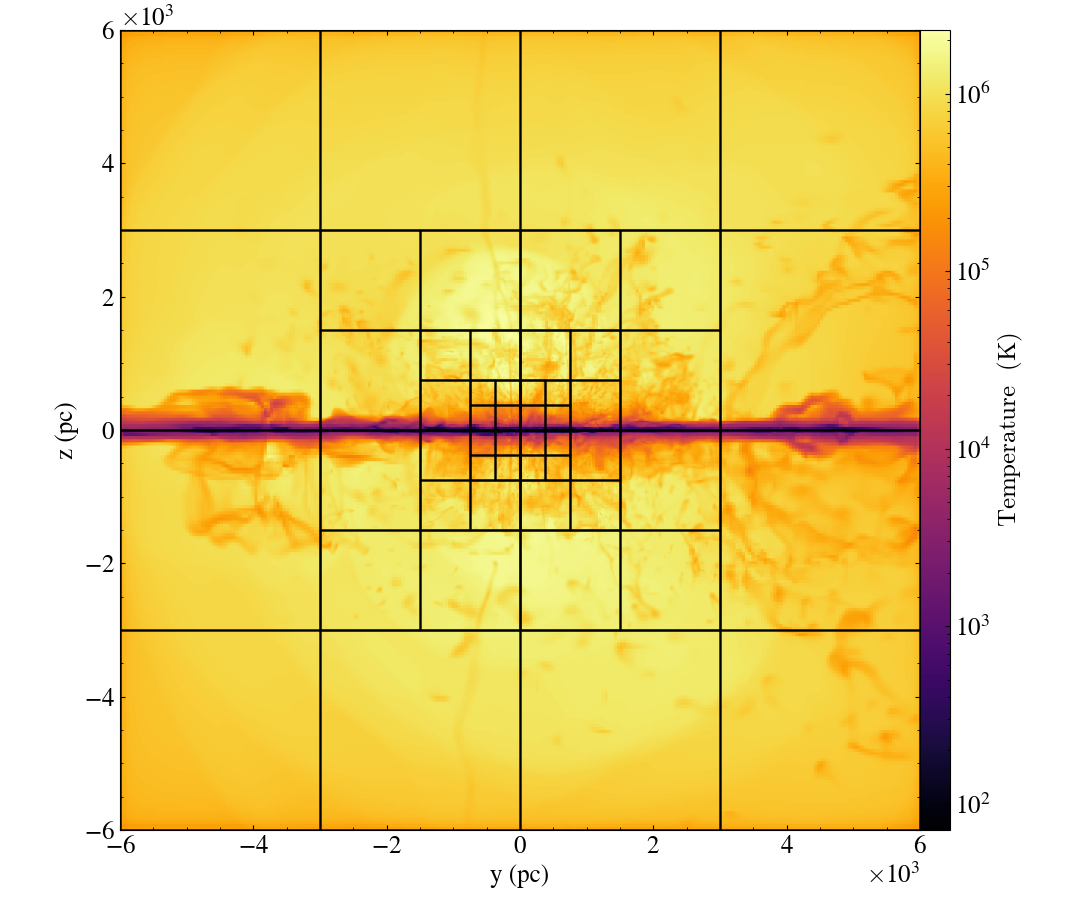

In [12]:
slc = yt.ProjectionPlot(dyt, "x", ("gas", "temperature"),weight_field=("gas","density"))
slc.set_cmap(("gas", "temperature"), "inferno")
slc.set_unit(("gas", "temperature"), "K")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)

#slc.save("yt_temp.png")
slc.show()

yt : [INFO     ] 2026-06-07 23:08:15,195 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 23:08:15,196 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 23:08:15,199 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 23:08:15,200 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 23:08:15,201 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



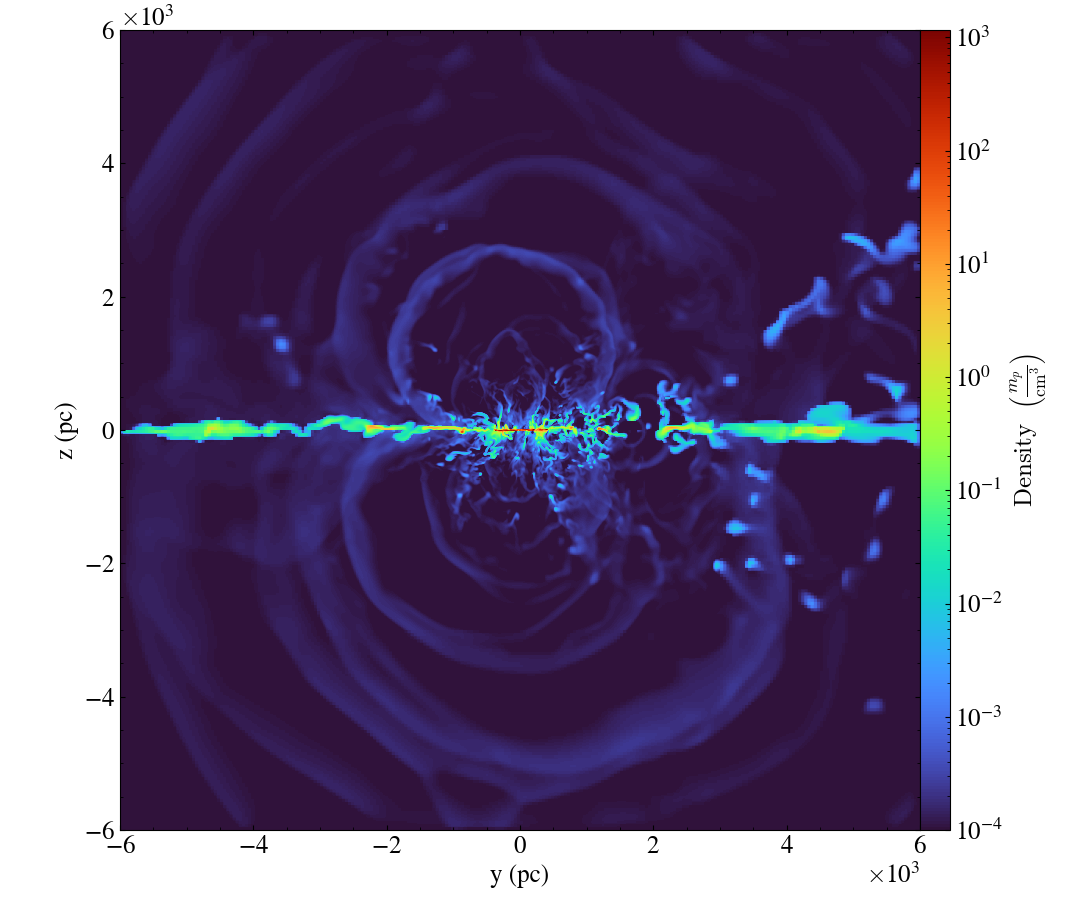

In [26]:
slc = yt.SlicePlot(dyt, "x", ("gas", "density"))
slc.set_cmap(("gas", "density"), "turbo")
slc.set_unit(("gas", "density"), "mp/cm**3")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
#slc.annotate_grids(cmap=None)
#slc.annotate_streamlines(("gas", "velocity_y"), ("gas", "velocity_z"), density=2, color='white')
#slc.save("slice_dens_streamlines.png")#,bbox_inches='tight', dpi=300)
slc.show()

yt : [INFO     ] 2026-06-07 22:49:38,195 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:38,196 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:38,199 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:38,199 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:38,200 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



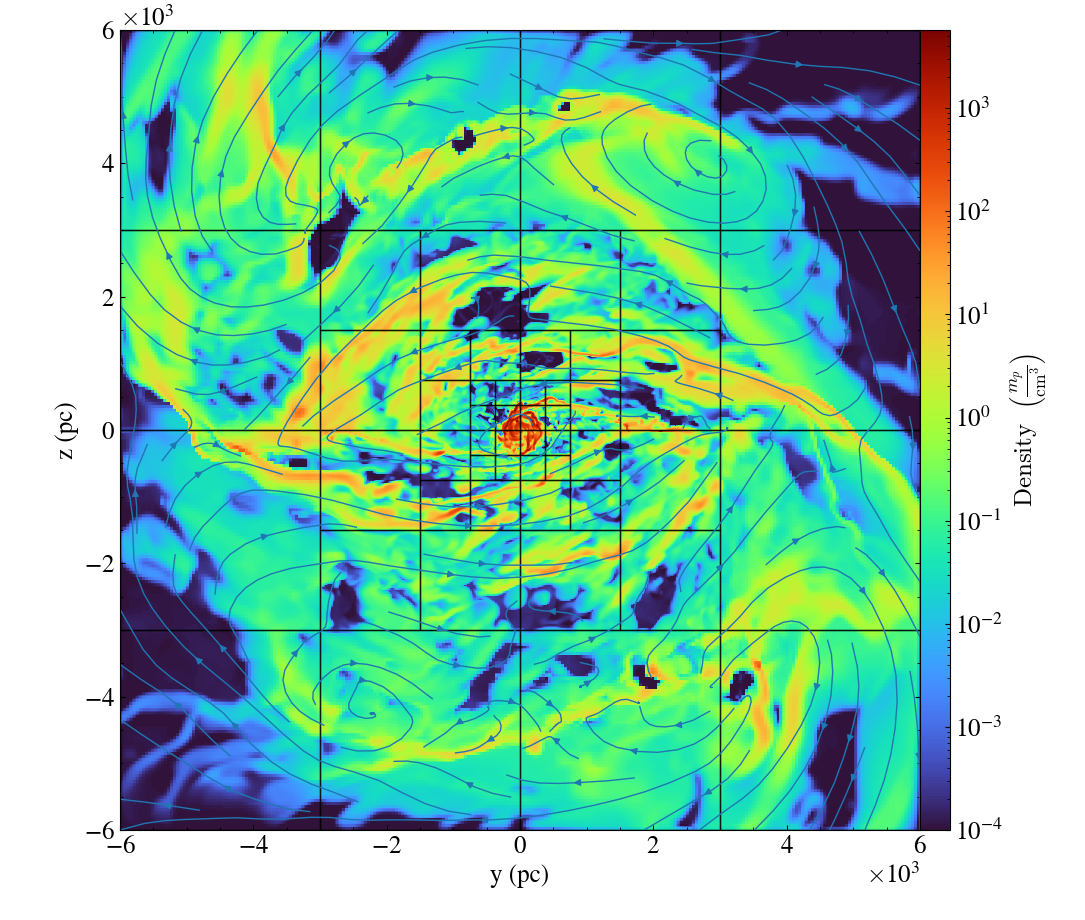

In [14]:
slc = yt.SlicePlot(dyt, "z", ("gas", "density"))
slc.set_cmap(("gas", "density"), "turbo")
slc.set_unit(("gas", "density"), "mp/cm**3")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)
slc.annotate_streamlines(("gas", "velocity_x"), ("gas", "velocity_y"))
#slc.save("slice_dens_faceon.png")
slc.show()

yt : [INFO     ] 2026-06-07 22:49:48,527 Projection completed
yt : [INFO     ] 2026-06-07 22:49:48,531 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:48,532 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:48,535 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:48,536 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:48,537 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800
yt : [INFO     ] 2026-06-07 22:49:48,964 Saving plot yt_dens_faceon.png



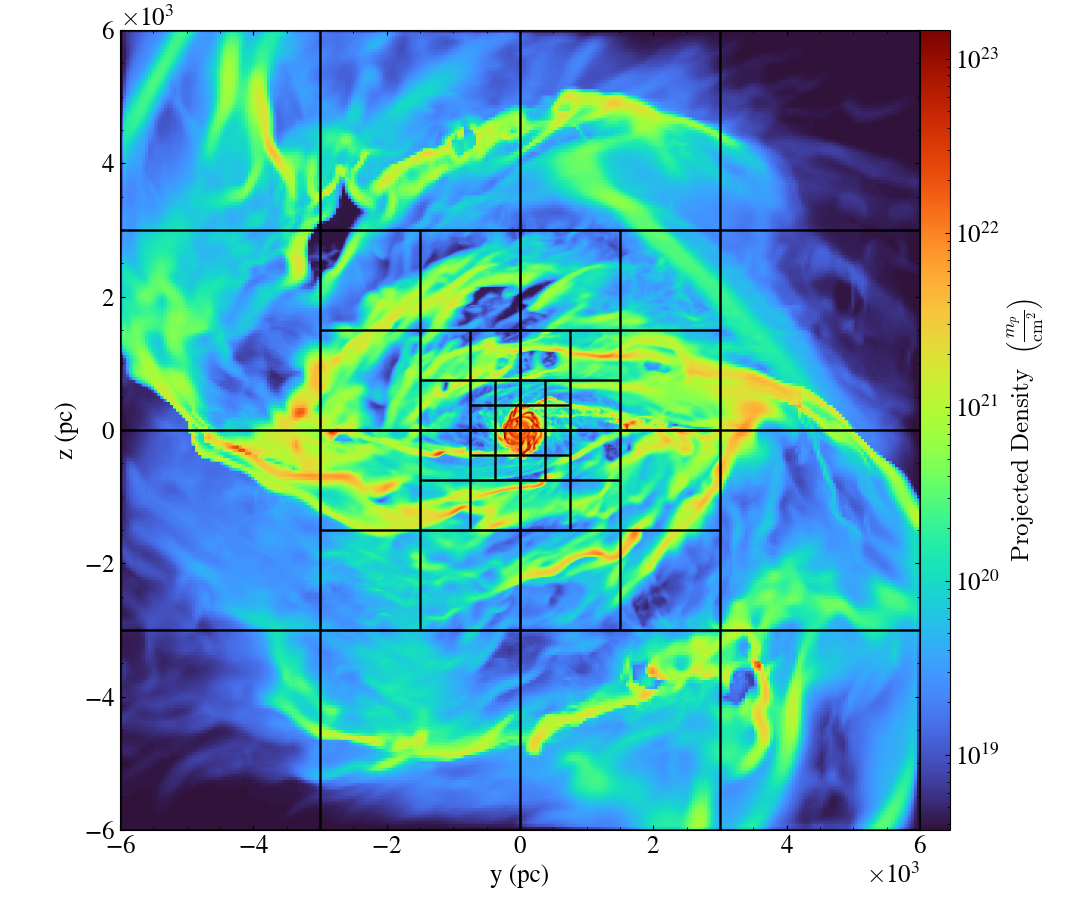

In [15]:
slc = yt.ProjectionPlot(dyt, "z", ("gas", "density"))
slc.set_cmap(("gas", "density"), "turbo")
slc.set_unit(("gas", "density"), "mp/cm**2")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)
slc.save("yt_dens_faceon.png")
slc.show()

yt : [INFO     ] 2026-06-07 22:49:58,942 Projection completed
yt : [INFO     ] 2026-06-07 22:49:58,946 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:58,946 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:58,950 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:58,951 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:49:58,952 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



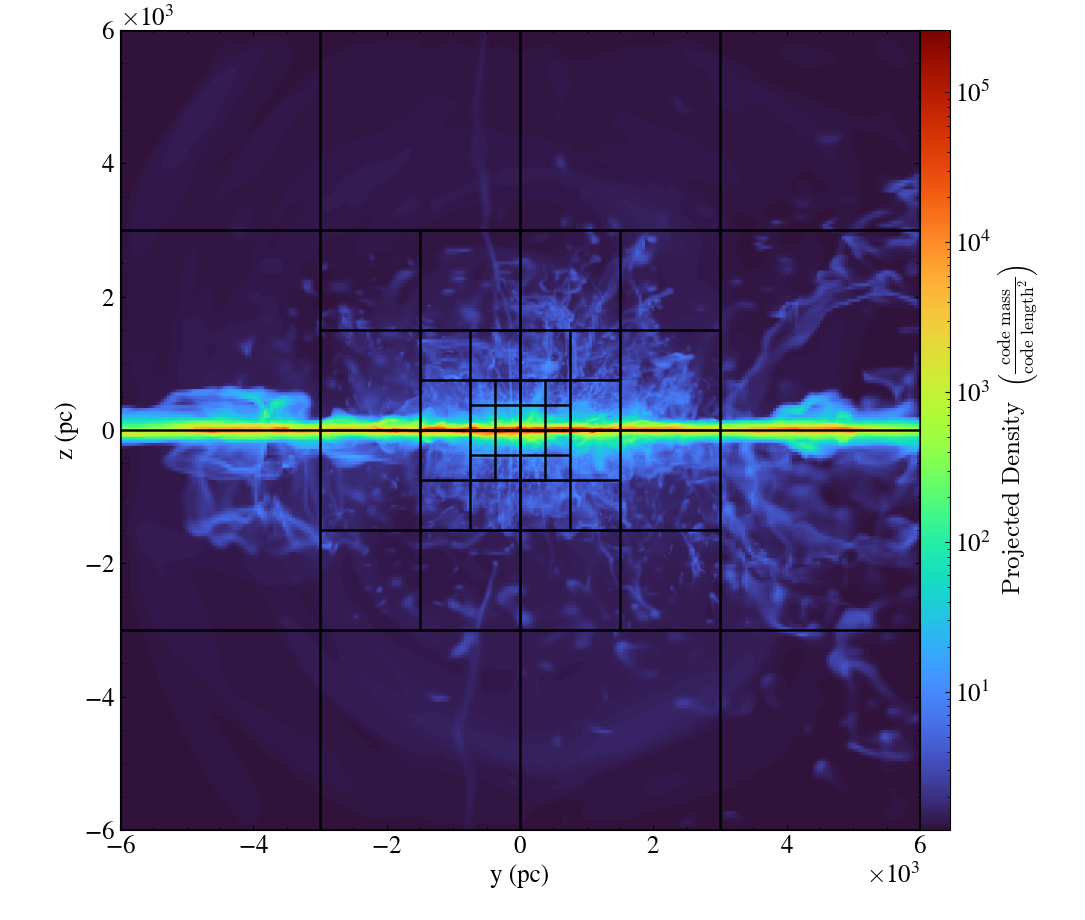

In [16]:
slc = yt.ProjectionPlot(dyt, "x", ("gas", "density"))
slc.set_cmap(("gas", "density"), "turbo")
#slc.set_unit(("gas", "density"), "mp/cm**3")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)
#slc.save("yt_dens.png")
slc.show()

pyxsim : [WARNING  ] 2026-06-07 22:49:59,735 For the 'cloudy' model, the only available abundance table is 'feld', so using that one.


pyxsim : [INFO     ] 2026-06-07 22:50:00,414 kT_min = 0.2 keV
pyxsim : [INFO     ] 2026-06-07 22:50:00,415 kT_max = 64 keV
pyxsim : [WARNING  ] 2026-06-07 22:50:00,417 Not all fields have the same field type! Fields used: [('gas', 'density'), ('gas', 'temperature'), ('athena_pp', 'metallicity')]
pyxsim : [INFO     ] 2026-06-07 22:50:00,417 Using emission measure field '('gas', 'density')'.
pyxsim : [INFO     ] 2026-06-07 22:50:00,418 Using temperature field '('gas', 'temperature')'.
yt : [INFO     ] 2026-06-07 22:50:40,336 Projection completed
yt : [INFO     ] 2026-06-07 22:50:40,340 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:50:40,341 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:50:40,344 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:50:40,345 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:50:40,346 Making a fixed resolution buffer of (('gas', 'xray_photon_count_rate_0.6_1_keV')) 800 by 800



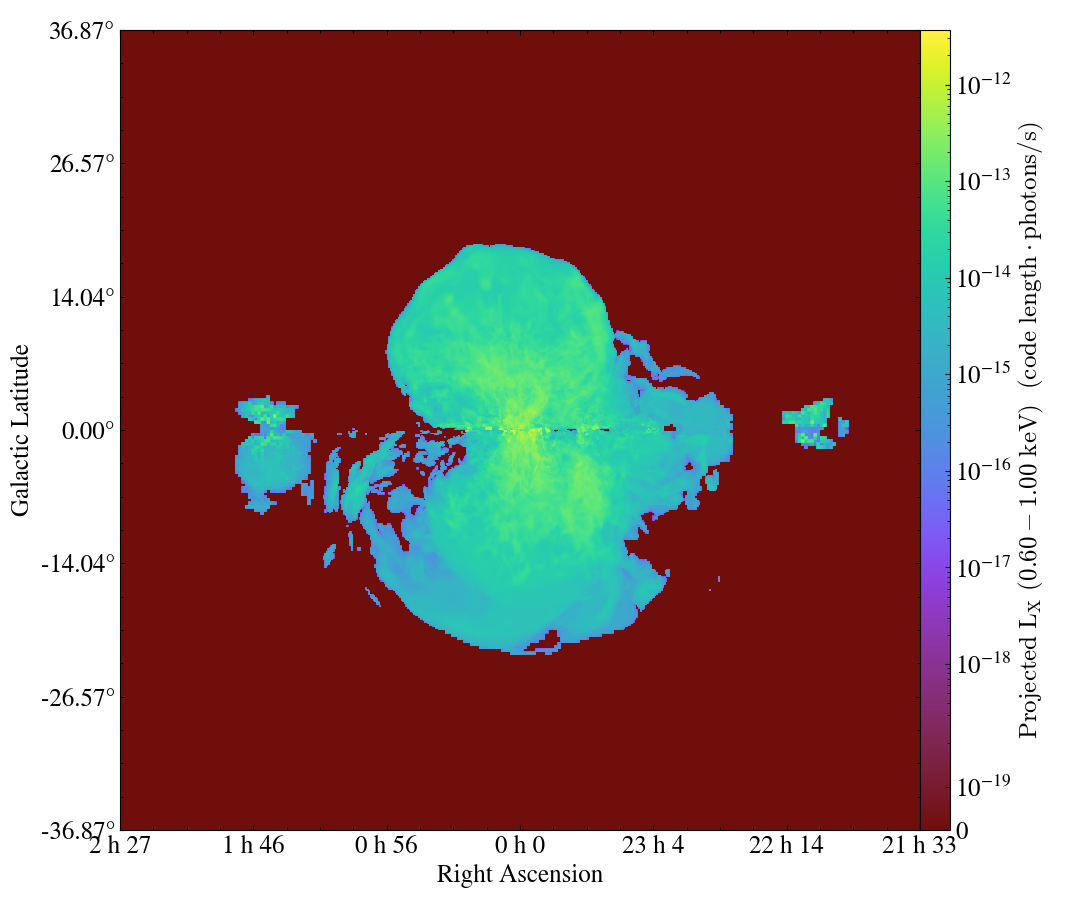

In [17]:
from matplotlib.ticker import FuncFormatter
import pyxsim
from math import floor
D = 8000
def y_to_angle( y, pos ):
    theta = np.arctan(y / D)
    return f"{np.degrees(theta):.2f}°"
def x_to_RA( x, pos ):
    theta = np.arctan(-x / D)
    if theta < 0:
        theta += 2*np.pi#- theta
    RA = theta * 12 / np.pi
    hour = int( floor( RA ) )
    min = round( ( RA - hour ) * 60 )
    return f"{hour} h {min}"
thermal_model  = pyxsim.CIESourceModel( "cloudy", 0.2, 11, 10000, ( "athena_pp", "metallicity" ), kT_min=0.2, emission_measure_field=( "gas", "density" )  )
#thermal_model  = pyxsim.CIESourceModel( "cloudy", 0.2, 11, 10000, 1, kT_min=0.2, emission_measure_field=( "gas", "density" )  )
#thermal_model2 = pyxsim.IGMSourceModel( "cloudy", 0.05, 11, 10000, ( "athena_pp", "metallicity" ), kT_min=0.1, emission_measure_field=( "gas", "density" )  )
xray = thermal_model.make_source_fields( dyt, 0.6, 1 )
prj = yt.ProjectionPlot(
    dyt, "x", ("gas", 'xray_photon_count_rate_0.6_1_keV') )#, weight_field=( "gas", "mass" ) )
#)
#prj.set_unit( ("gas", 'xray_emissivity_0.6_1_keV'), "erg/s/cm**2" )
prj.set_axes_unit( 'pc' )
prj.set_ylabel('Galactic Latitude')
prj.set_xlabel('Right Ascension')

prj._setup_plots()
ax = prj.plots[("gas", 'xray_photon_count_rate_0.6_1_keV')].axes
ax.yaxis.set_major_formatter(FuncFormatter(y_to_angle))
ax.xaxis.set_major_formatter(FuncFormatter(x_to_RA))
prj.show()

In [18]:
xray

[('gas', 'xray_emissivity_0.6_1_keV'),
 ('gas', 'xray_luminosity_0.6_1_keV'),
 ('gas', 'xray_photon_emissivity_0.6_1_keV'),
 ('gas', 'xray_photon_count_rate_0.6_1_keV')]

yt : [INFO     ] 2026-06-07 22:51:38,356 Projection completed
yt : [INFO     ] 2026-06-07 22:51:38,360 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:51:38,361 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:51:38,364 xlim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:51:38,365 ylim = -6000.000000 6000.000000
yt : [INFO     ] 2026-06-07 22:51:38,366 Making a fixed resolution buffer of (('gas', 'xray_emissivity_0.6_1_keV')) 800 by 800


Simulation extent: x=[-6000, 6000] pc, y=[-6000, 6000] pc
Max angle: RA=36.9°, Dec=36.9°
RA range:  [0.1°, 359.9°]
Dec range: [-36.9°, 36.9°]


/home/cmz_colab/.local/lib/python3.10/site-packages/skyproj/_skyproj.py:636: FutureWarning: skyproj.pcolormesh() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.pcolormesh()
  warnings.warn(


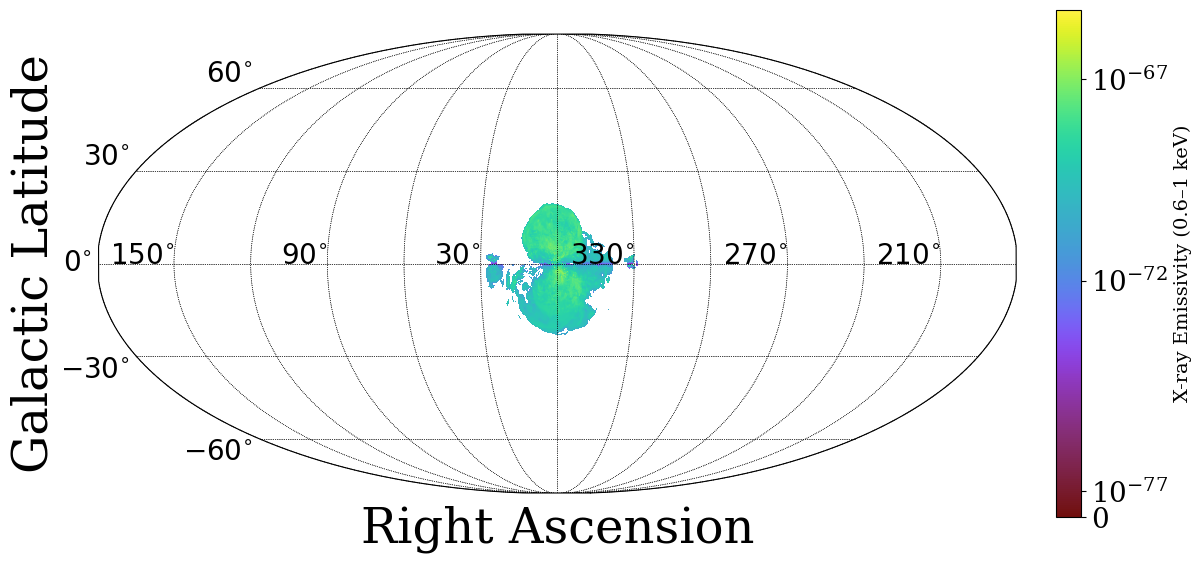

In [19]:
import skyproj

D = 8000  # pc — observer distance

# --- 1. Extract yt image ---
prj = yt.ProjectionPlot(
    dyt, "x", ("gas", "xray_emissivity_0.6_1_keV"), weight_field=("gas", "mass")
)
prj.set_axes_unit("pc")
prj._setup_plots()

yt_plot = prj.plots[("gas", "xray_emissivity_0.6_1_keV")]
yt_ax   = yt_plot.axes
img     = yt_ax.get_images()[0]
data    = img.get_array().copy()
extent  = img.get_extent()          # [xmin_pc, xmax_pc, ymin_pc, ymax_pc]
xmin_pc, xmax_pc, ymin_pc, ymax_pc = extent

print(f"Simulation extent: x=[{xmin_pc:.0f}, {xmax_pc:.0f}] pc, "
      f"y=[{ymin_pc:.0f}, {ymax_pc:.0f}] pc")
print(f"Max angle: RA={np.degrees(np.arctan(abs(xmax_pc)/D)):.1f}°, "
      f"Dec={np.degrees(np.arctan(abs(ymax_pc)/D)):.1f}°")

# --- 2. Build pixel-center coordinate grids ---
ny, nx = data.shape
# pixel centers (not edges)
xs_pc = np.linspace(xmin_pc, xmax_pc, nx)
ys_pc = np.linspace(ymin_pc, ymax_pc, ny)
XX, YY = np.meshgrid(xs_pc, ys_pc)

# Angular distance from observer at (D, 0, 0) looking toward Galactic center
# RA: arctan of transverse x offset (note sign convention: RA increases left)
RA_deg  = np.degrees(np.arctan2(-XX, D)) % 360   # 0–360°
Dec_deg = np.degrees(np.arctan2( YY, np.sqrt(XX**2 + D**2)))  # true elevation

# --- 3. Sanity-check the angular range ---
print(f"RA range:  [{RA_deg.min():.1f}°, {RA_deg.max():.1f}°]")
print(f"Dec range: [{Dec_deg.min():.1f}°, {Dec_deg.max():.1f}°]")

# --- 4. Mask zeros/negatives ---
masked_data = np.ma.masked_where(data <= 0, data)

cmap = img.cmap
cmap.set_bad(color='none')
norm = img.norm

# --- 5. pcolormesh needs CORNER coordinates, not centers ---
# Compute edge grids (shape ny+1, nx+1) for pcolormesh
xs_edge = np.linspace(xmin_pc, xmax_pc, nx + 1)
ys_edge = np.linspace(ymin_pc, ymax_pc, ny + 1)
XXe, YYe = np.meshgrid(xs_edge, ys_edge)
RA_edge  = np.degrees(np.arctan2(-XXe, D)) % 360
Dec_edge = np.degrees(np.arctan2( YYe, np.sqrt(XXe**2 + D**2)))

# --- 6. Plot ---
fig, raw_ax = plt.subplots(figsize=(12, 6))
sp = skyproj.MollweideSkyproj(
    ax=raw_ax,
    lon_0=0,          # center on RA=0 (Galactic center)
    celestial=True,
    gridlines=True,
)

# pcolormesh with explicit 2D corner arrays — no smearing
pcm = sp.pcolormesh(
    RA_edge, Dec_edge, masked_data,
    norm=norm,
    cmap=cmap,
    rasterized=True,
)

sp.ax.set_xlabel("Right Ascension")
sp.ax.set_ylabel("Galactic Latitude")
fig.colorbar(pcm, ax=sp.ax, label="X-ray Emissivity (0.6–1 keV)",
             fraction=0.03, pad=0.04)
plt.tight_layout()
plt.show()

In [43]:
from yt.data_objects.level_sets.api import *

ds = dyt.disk( [ 0,0,0 ], [ 0, 0, 1 ], ( 12, "kpc" ), ( 500, "pc" ) )
master_clump = Clump( ds, ( "gas", "density" ) )

In [44]:
c_min = ds["gas", "density"].min()
c_max = ds["gas", "density"].max()
step = 10.0
find_clumps(master_clump, c_min, c_max, step)

yt : [INFO     ] 2026-05-29 21:37:20,237 Finding clumps: min: 1.000000e-04, max: 8.525812e+03, step: 10.000000
yt : [INFO     ] 2026-05-29 21:37:22,440 Linking node (80) contours.
yt : [INFO     ] 2026-05-29 21:37:30,719 Linked.
Updating joins ... : 100%|██████████| 80/80 [00:00<00:00, 387.12it/s]
yt : [INFO     ] 2026-05-29 21:37:31,933 Finding clumps: min: 1.000000e-03, max: 8.525812e+03, step: 10.000000
yt : [INFO     ] 2026-05-29 21:37:31,935 Wiping out existing children clumps: 1.
yt : [INFO     ] 2026-05-29 21:37:32,508 Linking node (80) contours.
yt : [INFO     ] 2026-05-29 21:37:40,830 Linked.
Updating joins ... : 100%|██████████| 80/80 [00:00<00:00, 279.09it/s]
yt : [INFO     ] 2026-05-29 21:37:49,820 Investigating 373 children.
yt : [INFO     ] 2026-05-29 21:37:49,822 Finding clumps: min: 1.000000e-02, max: 8.525812e+03, step: 10.000000
yt : [INFO     ] 2026-05-29 21:37:51,795 Linking node (80) contours.
yt : [INFO     ] 2026-05-29 21:38:00,110 Linked.
Updating joins ... : 10

KeyboardInterrupt: 

In [ ]:
master_clump[ "gas", "density"]

unyt_array([1.71981178e-04, 1.72967342e-04, 1.73159096e-04, ...,
       1.17250444e-02, 2.27397612e-01, 5.06051466e-01], 'code_mass/code_length**3')

yt : [INFO     ] 2026-05-21 23:02:26,191 Projection completed
yt : [INFO     ] 2026-05-21 23:02:26,194 xlim = -12000.000000 12000.000000
yt : [INFO     ] 2026-05-21 23:02:26,194 ylim = -12000.000000 12000.000000
yt : [INFO     ] 2026-05-21 23:02:26,197 xlim = -12000.000000 12000.000000
yt : [INFO     ] 2026-05-21 23:02:26,198 ylim = -12000.000000 12000.000000
yt : [INFO     ] 2026-05-21 23:02:26,199 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800
yt : [INFO     ] 2026-05-21 23:02:26,602 Pixelizing contour 0
yt : [INFO     ] 2026-05-21 23:02:28,152 Pixelizing contour 1
yt : [INFO     ] 2026-05-21 23:02:28,177 Pixelizing contour 2
yt : [INFO     ] 2026-05-21 23:02:28,199 Pixelizing contour 3
yt : [INFO     ] 2026-05-21 23:02:28,221 Pixelizing contour 4
yt : [INFO     ] 2026-05-21 23:02:28,243 Pixelizing contour 5
yt : [INFO     ] 2026-05-21 23:02:28,266 Pixelizing contour 6
yt : [INFO     ] 2026-05-21 23:02:28,289 Pixelizing contour 7
yt : [INFO     ] 2026-05-21 23:02


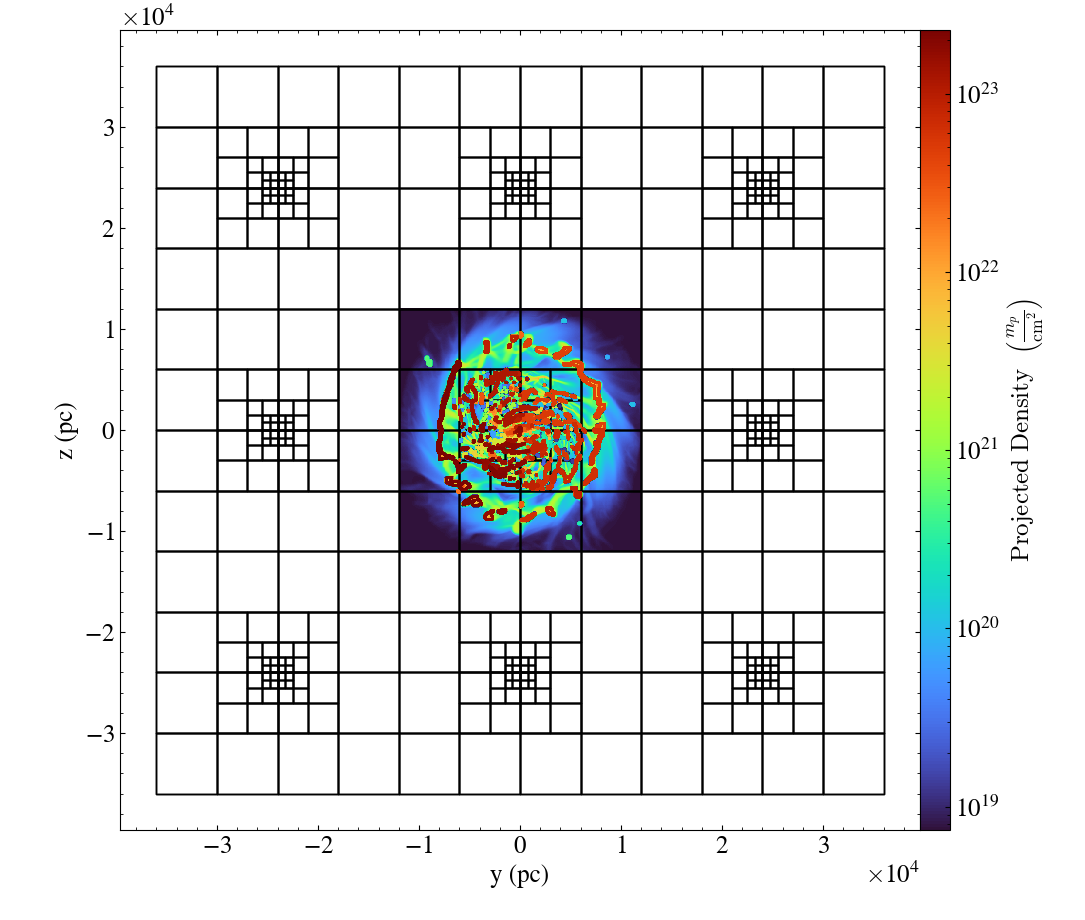

In [ ]:
slc = yt.ProjectionPlot(dyt, "z", ("gas", "density"))
slc.set_cmap(("gas", "density"), "turbo")
slc.set_unit(("gas", "density"), "mp/cm**2")
slc.set_axes_unit( 'pc' )
slc.set_xlabel('y (pc)')
slc.set_ylabel('z (pc)')
slc.annotate_grids(cmap=None)
slc.annotate_clumps( master_clump.leaves )
slc.show()

In [ ]:
clumpmasses = []
for clump in master_clump:
    clumpmasses.append( np.sum( clump["gas","mass"] ) )
clumpmasses = np.array( clumpmasses )

In [ ]:
for clump in master_clump:
    print( clump[ "gas"])

(1.0, 100.0)

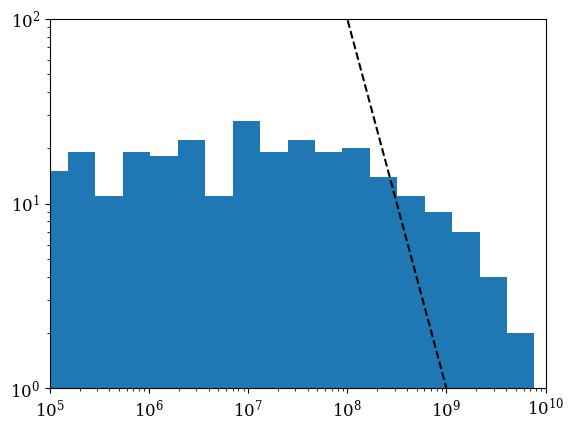

In [ ]:
logcm = np.log10( clumpmasses )
bins = 10**np.linspace( logcm.min(), logcm.max(), 40 )
plt.hist( clumpmasses, bins=bins )
plt.plot( bins, 10**18*bins**-2, '--k' )
plt.xscale('log')
plt.yscale('log')
plt.xlim( [ 1e5, 1e10 ] )
plt.ylim( [ 1e0, 1e2 ] )

In [ ]:
fn = master_clump.save_as_dataset(fields=["density", "mass"])

yt : [INFO     ] 2026-05-21 23:27:31,341 Saving field data to yt dataset: tmplgm2tep7_clump_0.h5.
